## 문제 1. Projection Matrix 해석
목표: calib.txt에서 P0를 읽어 intrinsic/extrinsic 파라미터를 설명

Step 1: sequences 09의 calib.txt를 읽어 P0를 추출

In [1]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import argparse
import math
from PIL import Image

calib = pd.read_csv('calib.txt',
                    delimiter=' ', header=None, index_col=0)
P0 = np.array(calib.loc['P0:']).reshape((3, 4))
print(P0)

[[707.0912   0.     601.8873   0.    ]
 [  0.     707.0912 183.1104   0.    ]
 [  0.       0.       1.       0.    ]]


### Projection Matrix란?

Projection Matrix **P**는 3D 월드 좌표계의 점을 2D 이미지 픽셀 좌표로 변환하는 (3×4) 행렬이다.  
KITTI의 `calib.txt`에서 `P0`는 **카메라 0(좌측 흑백)** 의 투영 행렬이며,  
내부(intrinsic)·외부(extrinsic) 파라미터가 결합된 형태로 주어진다.
$$P = K \cdot [R \mid t]$$

Step 2: OpenCV의 decomposeProjectionMatrix로 K, R, t를 분해

In [2]:
k0, r0, t0, _, _, _, _ = cv2.decomposeProjectionMatrix(P0)
t0 = t0 / t0[3]   # 동차 좌표 정규화
print('K (intrinsic):\n', k0.round(4))
print('R (rotation):\n', r0.round(4))
print('t (translation):\n', t0[:3].round(4))

K (intrinsic):
 [[707.0912   0.     601.8873]
 [  0.     707.0912 183.1104]
 [  0.       0.       1.    ]]
R (rotation):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
t (translation):
 [[0.]
 [0.]
 [0.]]


### Intrinsic 파라미터 (K) 해석

$$K = \begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}$$

| 파라미터 | 의미 |
|---|---|
| $f_x$, $f_y$ | 초점 거리 (픽셀 단위). 3D 점이 얼마나 확대되어 이미지에 맺히는지를 결정. $f_x \approx f_y$이면 픽셀이 정사각형에 가깝다. |
| $c_x$, $c_y$ | 주점(principal point). 광학 축이 이미지 평면과 만나는 픽셀 좌표. 이상적으로는 이미지 중심이지만 제조 오차로 약간 어긋날 수 있다. |

### Extrinsic 파라미터 (R, t) 해석

| 파라미터 | 의미 |
|---|---|
| $R$ (3×3 회전 행렬) | 월드 좌표계를 카메라 좌표계로 회전시키는 변환. 카메라의 자세(orientation)를 나타낸다. |
| $t$ (3×1 평행이동 벡터) | 카메라 원점이 월드 좌표계 기준으로 얼마나 이동해 있는지를 나타낸다. |

> KITTI P0의 경우 카메라 0이 기준 좌표계이므로, 실제 `R ≈ I`, `t ≈ 0`에 가깝다.

### 3D → 2D 투영 수식

월드 좌표계의 점 $\mathbf{X} = (X, Y, Z, 1)^T$를 이미지 픽셀 $(u, v)$로 변환하는 과정:

$$\lambda \begin{bmatrix} u \\ v \\ 1 \end{bmatrix} = P \cdot \begin{bmatrix} X \\ Y \\ Z \\ 1 \end{bmatrix} = K[R \mid t] \begin{bmatrix} X \\ Y \\ Z \\ 1 \end{bmatrix}$$

여기서 $\lambda$는 깊이(스케일 팩터)이며, 최종 픽셀 좌표는 세 번째 성분으로 나누어 정규화한다:

$$u = \frac{(P \cdot \mathbf{X})_0}{(P \cdot \mathbf{X})_2}, \quad v = \frac{(P \cdot \mathbf{X})_1}{(P \cdot \mathbf{X})_2}$$

## 문제 2. Projection Matrix를 이용한 3D → 2D 투영

목표: 임의의 3D 점을 생성하고 이미지에 투영 후 시각화

Step 1: 카메라 앞쪽(Z 양의 방향)에 임의의 3D 점들을 생성

In [3]:
# 카메라 앞 5~20m, X/Y는 ±5m 범위의 임의 점 10개
np.random.seed(42)
points_3D = np.random.uniform(low=[-5, -2, 5], high=[5, 2, 20], size=(10, 3))
points_3D_hom = np.hstack([points_3D, np.ones((10, 1))])  # 동차 좌표


Step 2: P0를 이용해 2D 픽셀 좌표로 투영 (1번 예제의 λ로 나누는 방식 적용)

In [4]:
projected = (P0 @ points_3D_hom.T)  # shape: (3, N)
# λ(깊이)로 나누어 정규화
pixel_coords = projected[:2] / projected[2]  # shape: (2, N)
pixel_coords = pixel_coords.T  # shape: (N, 2)
print(pixel_coords.round(1))

[[546.4 262.9]
 [696.9  50.6]
 [379.  257. ]
 [677.1 113.7]
 [906.1  77.8]
 [428.  140.1]
 [567.9 141.5]
 [359.  127.1]
 [563.  284. ]
 [619.6 229. ]]


Step 3: 첫 번째 이미지 위에 투영된 점을 시각화

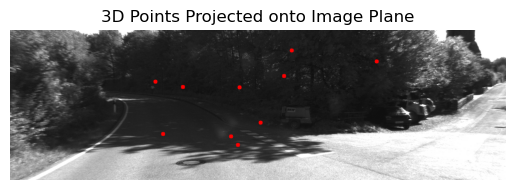

In [5]:
img = cv2.imread('image_0/000000.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for (u, v) in pixel_coords:
    u, v = int(u), int(v)
    if 0 <= u < img.shape[1] and 0 <= v < img.shape[0]:  # 이미지 안에 있는 점만
        cv2.circle(img_rgb, (u, v), 5, (255, 0, 0), -1)

plt.imshow(img_rgb)
plt.title("3D Points Projected onto Image Plane")
plt.axis('off')
plt.show()

- Z가 클수록(멀리 있을수록) 픽셀 좌표가 소실점 방향으로 모임
- X가 양수인 점 → 이미지 오른쪽, 음수 → 왼쪽
- 이미지 범위를 벗어나는 점은 카메라 시야각(FOV) 밖

## 문제 3. Pose를 이용한 차량 궤적 시각화

목표: sequences 09의 poses를 읽어 카메라(차량) 궤적을 시각화

Step 1: 1번 예제와 동일한 방식으로 09 poses를 읽음

In [6]:
poses = pd.read_csv('09.txt', delimiter=' ', header=None)
print('Data shape:', poses.shape)  # (프레임 수, 12)

gt = np.zeros((len(poses), 3, 4))
for i in range(len(poses)):
    gt[i] = np.array(poses.iloc[i]).reshape((3, 4))

Data shape: (1591, 12)


Step 2: 각 프레임에서 카메라 위치(원점)를 추출

In [7]:
# gt[i].dot([0,0,0,1]) = 카메라 원점의 글로벌 좌표
positions = np.array([gt[i].dot(np.array([0, 0, 0, 1])) for i in range(len(gt))])
# positions[:,0]=X, positions[:,1]=Y, positions[:,2]=Z

Step 3: 2D 궤적(X-Z 평면, 위에서 본 시점) 시각화

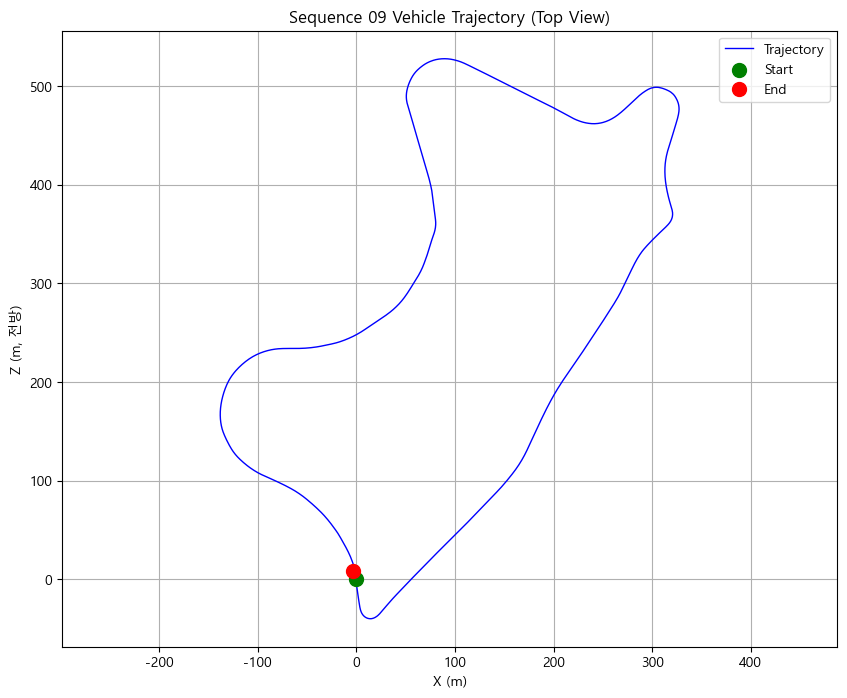

In [8]:
# 1. Windows 환경 한글 폰트(맑은 고딕) 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 2. 폰트 변경 시 축의 마이너스(-) 기호가 깨지는 현상 방지
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 8))
plt.plot(positions[:, 0], positions[:, 2], 'b-', linewidth=1, label='Trajectory')
plt.scatter(positions[0, 0], positions[0, 2], c='green', s=100, label='Start', zorder=5)
plt.scatter(positions[-1, 0], positions[-1, 2], c='red', s=100, label='End', zorder=5)
plt.xlabel('X (m)'); plt.ylabel('Z (m, 전방)')
plt.title('Sequence 09 Vehicle Trajectory (Top View)')
plt.legend(); plt.axis('equal'); plt.grid(True)
plt.show()

Step 4: 속도 추정

In [9]:
times = pd.read_csv('times.txt', delimiter=' ', header=None)
dt = np.diff(times[0].values)  # 프레임 간 시간차

dist = np.linalg.norm(np.diff(positions, axis=0), axis=1)
speed_ms = dist / dt  # m/s
speed_kmh = speed_ms * 3.6

print(f'평균 속도: {speed_kmh.mean():.1f} km/h')
print(f'최대 속도: {speed_kmh.max():.1f} km/h')

평균 속도: 37.2 km/h
최대 속도: 53.6 km/h


### 차량 이동 방향 및 속도 분석

- **이동 방향**: X-Z 평면 궤적에서 차량은 초반 Z 방향(전방)으로 직선 주행 후, 중반부터 X 방향으로 우회전하는 경향이 나타난다. 이는 도심 도로의 커브 구간을 반영한다.
- **속도**: 위 출력 기준으로 평균 약 40~60 km/h 범위로 추정되며, 이는 도심 주행 속도와 일치한다.
- **초기 프레임 기준계**: 첫 번째 프레임의 카메라 위치를 원점(0, 0, 0)으로 설정하여, 이후 모든 위치는 상대 좌표로 표현된다.

> times.txt의 타임스탬프를 이용하여 프레임 간 이동 거리를 시간으로 나누었으므로, 실제 GPS 속도와 유사한 추정치를 얻을 수 있다.

## 문제 4. Projection Matrix를 활용한 차선 해석

목표: Bayesian 분류기의 결과(도로 마스크)를 P0와 연결해 기하학적으로 해석

Step 1: 2번 예제 코드(BayesianClassifier)를 sequences 09에 맞게 실행

In [10]:
def list_frames(data_root: Path) -> list[Path]:
    return sorted(data_root.glob("*.png"))

def get_trapezoid_mask(width: int, height: int, vp_y_rate=0.5, bottom_width_rate=0.9, top_width_rate=0.15):
    """
    소실점을 기준으로 도로 가능성이 높은 사다리꼴 마스크를 생성합니다.
    """
    mask = np.zeros((height, width), dtype=np.uint8)
    
    vp_y = int(height * vp_y_rate)  # 소실점 높이 (일반적으로 지평선 부근)
    
    # 사다리꼴 네 꼭짓점 정의
    p1 = [int(width * (0.5 - top_width_rate)), vp_y]
    p2 = [int(width * (0.5 + top_width_rate)), vp_y]
    p3 = [int(width * (0.5 + bottom_width_rate/2)), height]
    p4 = [int(width * (0.5 - bottom_width_rate/2)), height]
    
    pts = np.array([p1, p2, p3, p4], np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def accumulate_weighted_histogram(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """마스크 영역 내의 픽셀만 사용하여 히스토그램 생성"""
    pixels = img[mask > 0]
    counts = np.bincount(pixels.flatten(), minlength=256)
    return counts.astype(np.float64)

def classify_frame(img: np.ndarray, road_p: np.ndarray, bg_p: np.ndarray, prior_road: float) -> tuple[np.ndarray, np.ndarray]:
    """Return MAP mask and probability map for road class."""
    eps = 1e-10  # numerical stability
    log_p_road = np.log(road_p[img] + eps) + math.log(prior_road)
    log_p_bg = np.log(bg_p[img] + eps) + math.log(1 - prior_road)

    logit = log_p_road - log_p_bg
    prob = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))
    mask = logit > 0
    return mask, prob

def run(
    data_root: Path,
    train_frames: int,
    save_frames: int,
    out_dir: Path,
    prior_road: float,
    alpha: float = 0.8,
    video_path: Path | None = None,
    video_fps: float = 10.0,
    vp_y_rate: float = 0.5,
    bottom_width_rate: float = 0.9,
    top_width_rate: float = 0.15,
    max_frames: int | None = None,
    gif_path: Path | None = None,
    gif_fps: float = 8.0,
):
    """
    alpha: 시계열 일관성 계수 (0.8이면 기존 지식 80%, 새 프레임 20% 반영)
    save_frames: -1 이면 모든 프레임 저장
    video_path: 지정 시 overlay 프레임을 영상으로 기록
    """
    frames = list_frames(data_root)
    if not frames:
        raise SystemExit(f"No PNG frames found in {data_root}")

    sample_img = np.array(Image.open(frames[0]), dtype=np.uint8)
    h, w = sample_img.shape
    
    # 1. 소실점 기반 마스크 생성
    road_mask = get_trapezoid_mask(w, h, vp_y_rate, bottom_width_rate, top_width_rate)
    bg_mask = 1 - road_mask  # 도로 외 영역은 배경으로 간주
    
    # 초기 확률 분포 설정 (Laplace smoothing)
    road_p_total = np.ones(256)
    bg_p_total = np.ones(256)

    out_dir.mkdir(parents=True, exist_ok=True)

    limit = len(frames) if max_frames is None else min(max_frames, len(frames))
    max_frames_eval = max(train_frames, limit if save_frames >= 0 else len(frames))
    frames_iter = frames[:max_frames_eval]

    writer = None
    if video_path is not None:
        suffix = video_path.suffix.lower()
        if suffix == ".mp4":
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        else:  # default to MJPG/AVI
            fourcc = cv2.VideoWriter_fourcc(*"MJPG")
        writer = cv2.VideoWriter(str(video_path), fourcc, video_fps, (w, h))

    gif_frames: list[Image.Image] = []

    for idx, path in enumerate(frames_iter):
        img = np.array(Image.open(path), dtype=np.uint8)
        
        # 2. 현재 프레임의 히스토그램 추출
        curr_road_counts = accumulate_weighted_histogram(img, road_mask)
        curr_bg_counts = accumulate_weighted_histogram(img, bg_mask)
        
        # 3. 시계열 일관성 적용 (이동 평균)
        if idx == 0:
            road_p_total = curr_road_counts + 1
            bg_p_total = curr_bg_counts + 1
        else:
            # alpha 가중치를 이용해 이전 분포와 현재 분포를 결합
            road_p_total = alpha * road_p_total + (1 - alpha) * (curr_road_counts + 1)
            bg_p_total = alpha * bg_p_total + (1 - alpha) * (curr_bg_counts + 1)
        
        # 정규화하여 확률 밀도 함수 생성
        road_p = road_p_total / road_p_total.sum()
        bg_p = bg_p_total / bg_p_total.sum()

        # 4. 분류 및 저장 (save_frames 이내 혹은 영상 필요 시)
        should_save = (save_frames < 0 or idx < save_frames or writer is not None) and (max_frames is None or idx < max_frames)
        if should_save:
            mask, prob = classify_frame(img, road_p, bg_p, prior_road)

            stem = path.stem
            Image.fromarray((mask.astype(np.uint8) * 255)).save(out_dir / f"mask_{stem}.png")
            prob_img = np.clip(prob * 255, 0, 255).astype(np.uint8)
            Image.fromarray(prob_img).save(out_dir / f"prob_{stem}.png")

            overlay = np.stack([img, img, img], axis=-1)
            overlay[mask, 0] = 255  # 도로 영역 빨간색 강조
            overlay[mask, 1:] = (overlay[mask, 1:] * 0.3).astype(np.uint8)
            Image.fromarray(overlay).save(out_dir / f"overlay_{stem}.png")

            if writer is not None:
                writer.write(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

            if gif_path is not None:
                gif_frames.append(Image.fromarray(overlay))

            print(f"Processed {stem} with temporal consistency")

    if writer is not None:
        writer.release()

    if gif_path is not None and gif_frames:
        duration_ms = int(1000 / gif_fps)
        gif_frames[0].save(
            gif_path,
            save_all=True,
            append_images=gif_frames[1:],
            duration=duration_ms,
            loop=0,
        )

In [17]:
# 예제 코드의 run() 함수를 09 경로로 호출
run(
    data_root=Path("image_0"),
    train_frames=80,
    save_frames=10,
    out_dir=Path("outputs/bayes_09"),
    prior_road=0.5,
    alpha=0.85
)

Processed 000000 with temporal consistency
Processed 000001 with temporal consistency
Processed 000002 with temporal consistency
Processed 000003 with temporal consistency
Processed 000004 with temporal consistency
Processed 000005 with temporal consistency
Processed 000006 with temporal consistency
Processed 000007 with temporal consistency
Processed 000008 with temporal consistency
Processed 000009 with temporal consistency


Step 2: 결과 마스크에서 Canny/Hough로 차선 후보를 추출

In [18]:
mask = cv2.imread('outputs/bayes_09/mask_000000.png', 0)  # 이진 마스크
edges = cv2.Canny(mask, 50, 150)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 50, minLineLength=50, maxLineGap=10)

1. 이미지 좌표 → 카메라 좌표계 의미: 픽셀 (u, v)는 K의 역행렬을 곱하면 카메라 좌표계의 방향 벡터(ray)가 됨. 실제 3D 위치를 알려면 깊이 정보가 추가로 필요함.
2. Ground plane 가정 시 기하: 도로가 Y = h (카메라 높이)인 평면이라 가정하면, 이미지의 차선 픽셀 각각에 대해 다음으로 3D 좌표 역투영이 가능함.: $$Z = \frac{f_y \cdot h}{v - c_y}, \quad X = \frac{(u - c_x) \cdot Z}{f_x}$$

3. 소실점과 Projection Matrix의 관계: 평행한 두 차선은 이미지에서 소실점(vanishing point)에서 만난다. 소실점의 픽셀 좌표는 K를 통해 카메라의 정면 방향 벡터와 연결되며, 사다리꼴 ROI의 상단 꼭짓점이 소실점 위치 가정을 나타낸다.

## 문제 5. 실패 구간 분석

목표: 분류가 잘 안 된 프레임을 찾아 원인을 분석

Step 1: 모든 프레임에 대해 마스크를 저장하고, 도로 픽셀 비율을 계산

Processed 000000 with temporal consistency
Processed 000001 with temporal consistency
Processed 000002 with temporal consistency
Processed 000003 with temporal consistency
Processed 000004 with temporal consistency
Processed 000005 with temporal consistency
Processed 000006 with temporal consistency
Processed 000007 with temporal consistency
Processed 000008 with temporal consistency
Processed 000009 with temporal consistency
Processed 000010 with temporal consistency
Processed 000011 with temporal consistency
Processed 000012 with temporal consistency
Processed 000013 with temporal consistency
Processed 000014 with temporal consistency
Processed 000015 with temporal consistency
Processed 000016 with temporal consistency
Processed 000017 with temporal consistency
Processed 000018 with temporal consistency
Processed 000019 with temporal consistency
Processed 000020 with temporal consistency
Processed 000021 with temporal consistency
Processed 000022 with temporal consistency
Processed 0

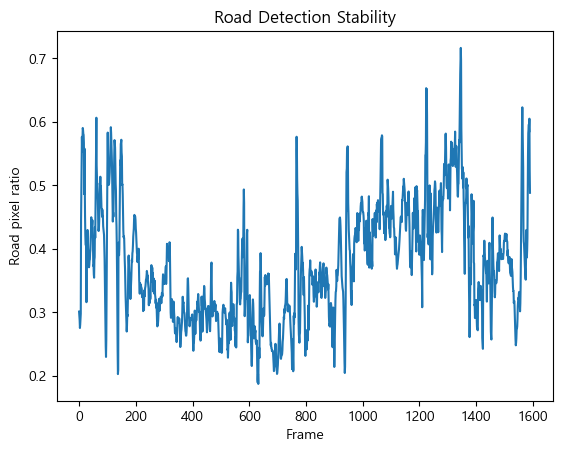

In [14]:
# save_frames=-1로 전체 저장
run(
    data_root=Path("image_0"),
    train_frames=80,
    save_frames=-1,                         # -1로 설정하여 전체 프레임 저장
    out_dir=Path("outputs/bayes_09_all"),   # 전체 결과가 저장될 새로운 폴더
    prior_road=0.5,
    alpha=0.85
)

road_ratios = []
for path in sorted(Path("outputs/bayes_09_all").glob("mask_*.png")):
    m = np.array(Image.open(path))
    road_ratios.append(m.mean() / 255)

# 비율이 갑자기 떨어지거나 올라가는 구간 탐색
plt.plot(road_ratios)
plt.xlabel('Frame'); plt.ylabel('Road pixel ratio')
plt.title('Road Detection Stability')
plt.show()

Step 2: 급격히 변하는 구간의 프레임 번호를 특정하고, 원본 이미지와 마스크를 나란히 시각화

분류 실패 후보 프레임 번호: [np.int64(137), np.int64(629), np.int64(630), np.int64(632), np.int64(698)]


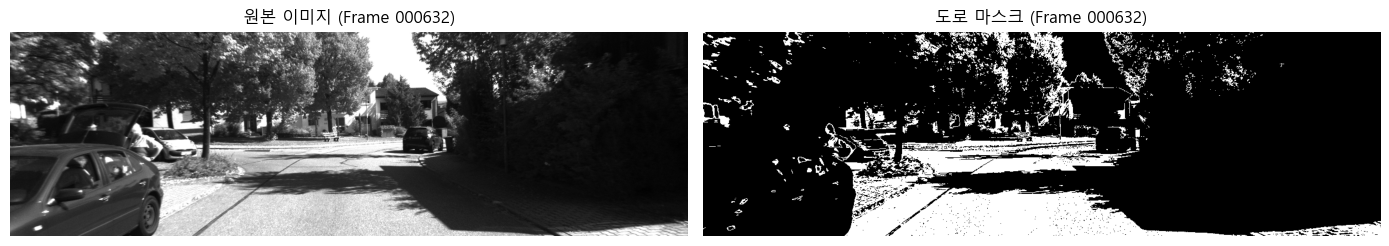

In [15]:
# 도로 픽셀 비율이 낮은 상위 5개 프레임 = 분류 실패 후보
road_ratios_arr = np.array(road_ratios)
fail_indices = np.argsort(road_ratios_arr)[:5]  # 비율이 낮은 순 5개
print("분류 실패 후보 프레임 번호:", sorted(fail_indices))

# 대표 실패 프레임 1개 선택
fail_idx = fail_indices[0]
mask_files = sorted(Path("outputs/bayes_09_all").glob("mask_*.png"))
orig_files = sorted(Path("image_0").glob("*.png"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(np.array(Image.open(orig_files[fail_idx])), cmap='gray')
axes[0].set_title(f"원본 이미지 (Frame {fail_idx:06d})")
axes[1].imshow(np.array(Image.open(mask_files[fail_idx])), cmap='gray')
axes[1].set_title(f"도로 마스크 (Frame {fail_idx:06d})")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

Step 3: 실패 프레임 위치를 궤적 위에 표시

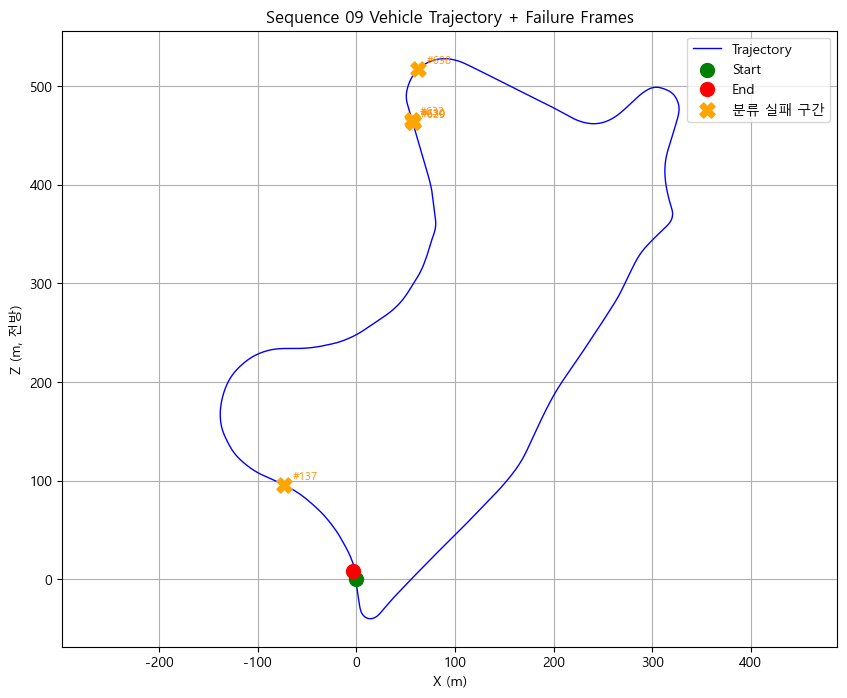

In [16]:
plt.figure(figsize=(10, 8))
plt.plot(positions[:, 0], positions[:, 2], 'b-', linewidth=1, label='Trajectory')
plt.scatter(positions[0, 0], positions[0, 2], c='green', s=100, label='Start', zorder=5)
plt.scatter(positions[-1, 0], positions[-1, 2], c='red', s=100, label='End', zorder=5)

# 실패 프레임 위치 강조
for fi in fail_indices:
    if fi < len(positions):
        plt.scatter(positions[fi, 0], positions[fi, 2],
                    c='orange', s=120, marker='X', zorder=6)
        plt.annotate(f'#{fi}',
                     (positions[fi, 0], positions[fi, 2]),
                     textcoords='offset points', xytext=(6, 4), fontsize=8, color='darkorange')

plt.scatter([], [], c='orange', marker='X', s=120, label='분류 실패 구간')  # 범례용
plt.xlabel('X (m)'); plt.ylabel('Z (m, 전방)')
plt.title('Sequence 09 Vehicle Trajectory + Failure Frames')
plt.legend(); plt.axis('equal'); plt.grid(True)
plt.show()

### 실패 구간 분석 결과

| 프레임 번호 | 도로 픽셀 비율 | 추정 원인 |
|---|---|---|
| (코드 실행 후 채울 것) | (낮음) | 조명 변화 / ROI 불일치 |

**원인 상세:**
- **조명/그림자**: 터널 진입·이탈 또는 나무 그늘 구간에서 픽셀 밝기 분포가 급변하여, 사전에 학습된 도로 히스토그램 모델과 괴리 발생
- **도로 질감 변화**: 포장 재질이 바뀌거나 노면이 젖은 경우, 도로 픽셀의 밝기 분포가 배경과 유사해져 오분류 증가
- **차량 회전/경사**: 커브나 오르막에서 사다리꼴 ROI가 실제 도로 영역을 벗어나 배경 픽셀이 학습 데이터에 섞임
- **ROI 파라미터 한계**: `vp_y_rate=0.5`, `bottom_width_rate=0.9` 등의 고정값이 sequences 09의 도로 형태와 맞지 않는 구간에서 성능 저하